Домашнее задание: Решающие деревья, ансамбли и бустинг

Датасет: [Bank Marketing Dataset](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset) (предсказание, подпишется ли клиент на депозит)

In [165]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/romanananev/.cache/kagglehub/datasets/janiobachmann/bank-marketing-dataset/versions/1


In [166]:
## Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso, Ridge, LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import statsmodels
from sklearn.preprocessing import StandardScaler

Первичный анализ данных ( 1 балл)

- Загрузите данные и выполните первичный анализ

- Проведите анализ распределения целевой переменной

- Выявите и обработайте пропущенные значения в данных
- Преобразуй категориальные данные в числовые (LabelEncoder)
- Разделите данные на обучающую и тестовую выборки в соотношении 80/20


In [167]:
df = pd.read_csv(f"{path}/bank.csv", sep=',')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


#### Не понятно считать ли значения unknown за пропуск. Это скорее всего не является пропуском, а просто говорит о том, что пользователь не указал, например, контакт. В теории это может нести какую-то информацию (лояльность клиента или готовность совершить сделку или тп), поэтому буду считать unknown значением, а не пропуском.

In [169]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [170]:
y = df['deposit']
X = df.drop(['deposit', 'duration'], axis = 1)

<Axes: xlabel='deposit', ylabel='Count'>

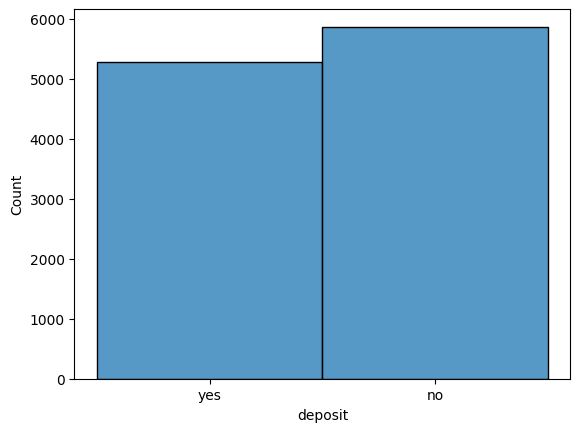

In [171]:
sns.histplot(y, bins = 'auto')

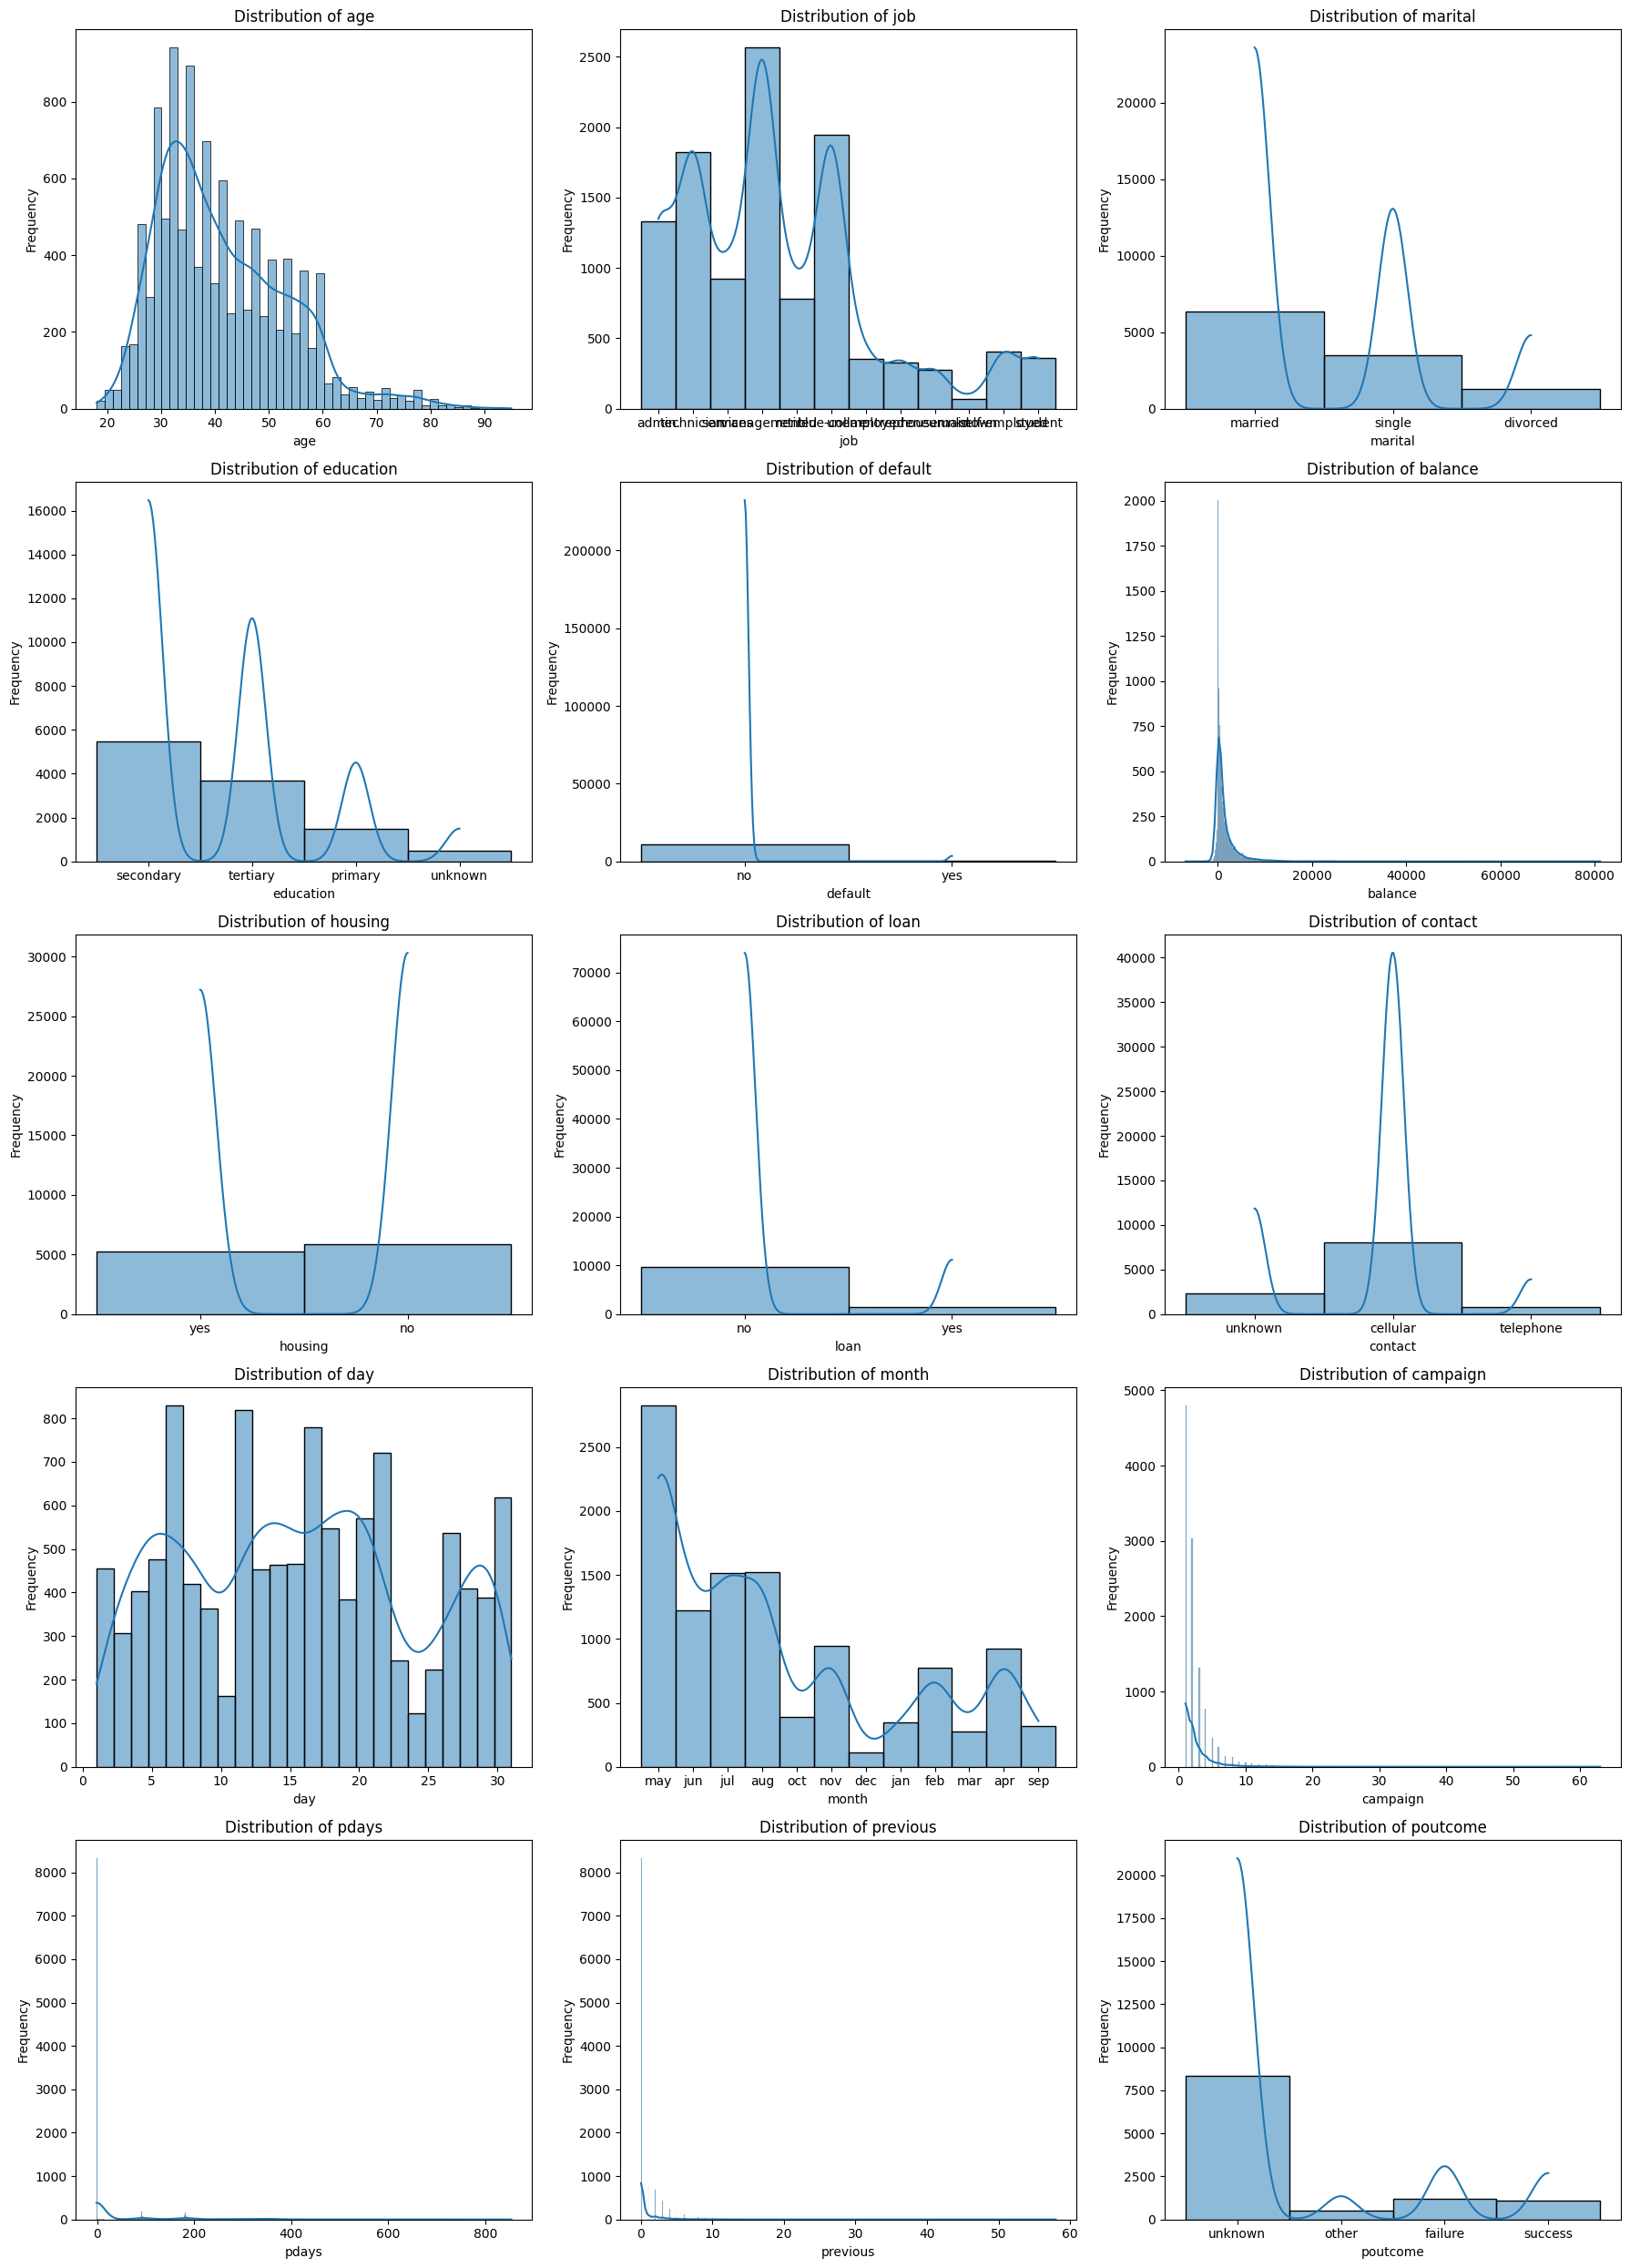

In [172]:
num_columns = X.shape[1]
num_rows = (num_columns + 2) // 3

plt.figure(figsize=(18, 5 * num_rows))

for i, column in enumerate(X.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(X[column], kde=True) # Use kde=True for kernel density estimate
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [173]:
#преобразование категориальных данных в числовые с использованием LabelEncoder
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(['object']).columns

print(f'Категориальные признаки: {cat_cols.tolist()}')

for i in cat_cols:
    LE = LabelEncoder()
    X[i] = LE.fit_transform(X[i])
    


Категориальные признаки: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [174]:
#сплит
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, test_size = 0.2, random_state=42, stratify = y)

Часть 1: Решающие деревья ( 3 балла)

Постройте решающее дерево для классификации с максимальной глубиной 3. Визуализируйте дерево и ответьте:

- Какие 3 признака оказались самыми важными на верхнем уровне дерева?

- Какой лист содержит наибольшее количество объектов и каково его предсказание?

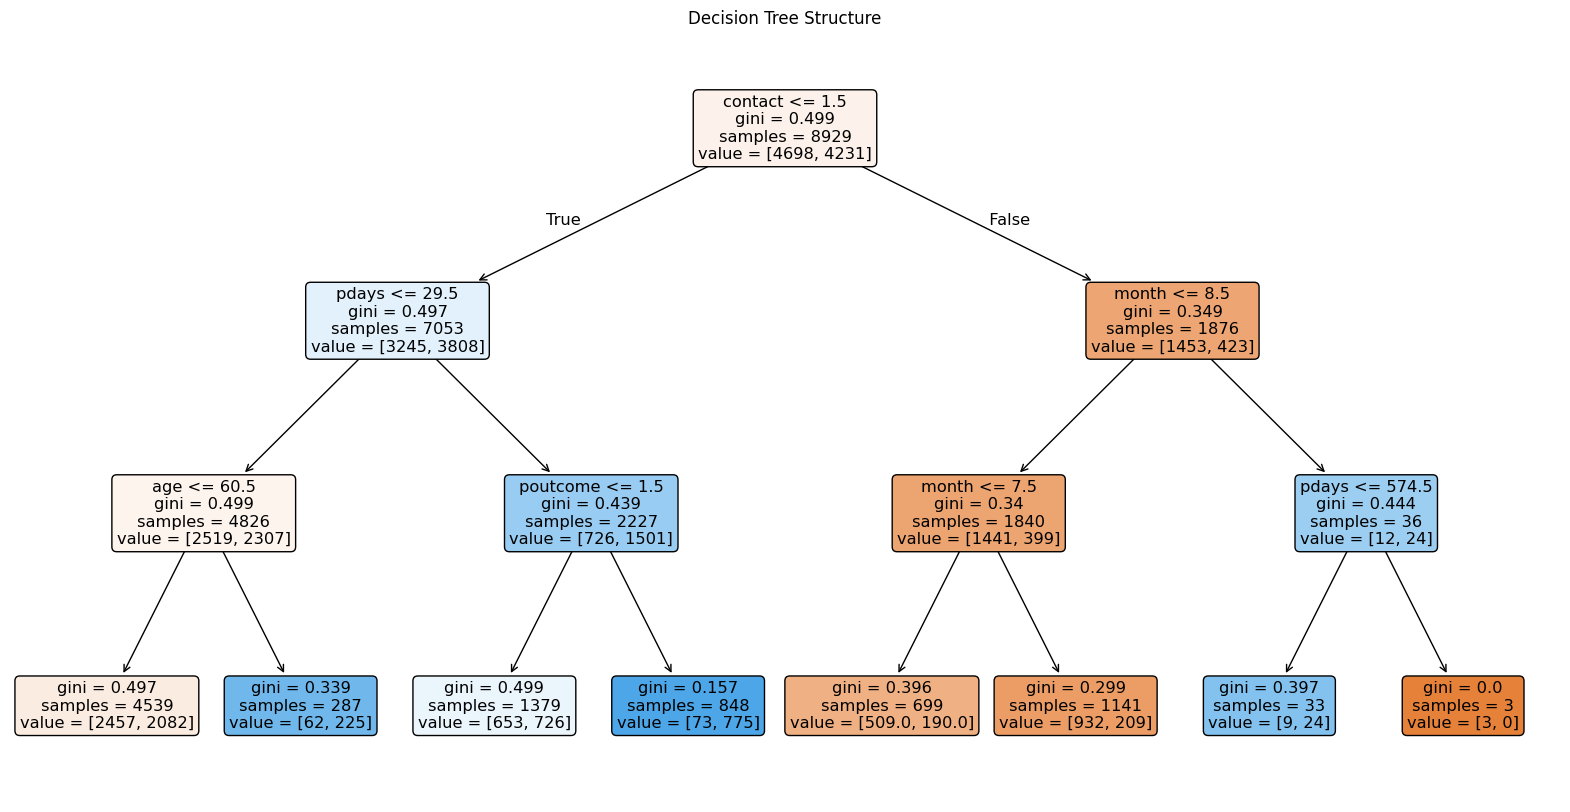

Топ 5 важнейших признаков в дереве:
 Признак  Важность
 contact  0.451602
poutcome  0.242975
   pdays  0.184864
     age  0.088038
   month  0.032521


In [175]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree_model = DecisionTreeClassifier(max_depth = 3, random_state=1)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(20, 10))
plot_tree(tree_model, filled=True, feature_names=X.columns.tolist(), rounded=True, proportion=False)
plt.title('Decision Tree Structure')
plt.show()

feature_importance_tree = tree_model.feature_importances_
importance_tree = pd.DataFrame({
    'Признак': X.columns,
    'Важность': feature_importance_tree
}).sort_values('Важность', ascending=False)

print("Топ 5 важнейших признаков в дереве:")
print(importance_tree.head(5).to_string(index=False))


Ответ на вопрос: Самое большое количество значений в листе = 4539 (самый левыq на картинке). Предсказываемое им значение равно 2457.2082

- Проведите эксперимент с разной глубиной дерева (от 2 до 10). Постройте график:

Ось X: глубина дерева

Ось Y: accuracy на тренировочной и тестовой выборках

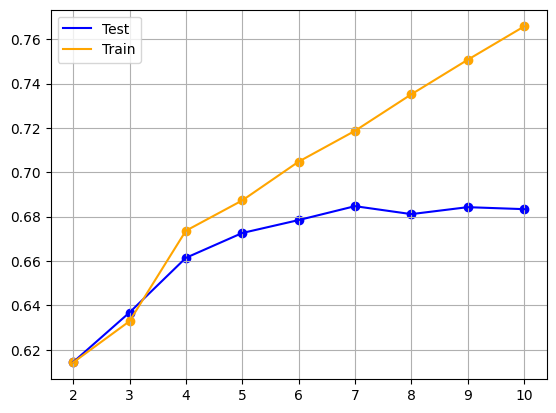

In [176]:
from sklearn.metrics import accuracy_score

accurs_test = []
accurs_train = []

depths = np.arange(2, 11)
for depth in depths:

    tree_model = DecisionTreeClassifier(max_depth = depth, random_state=1)
    #обучение
    tree_model.fit(X_train, y_train)
    #предсказание для test и train
    y_pred_tree_train = tree_model.predict(X_train)
    y_pred_tree_test = tree_model.predict(X_test)
    #accuracy для train и test
    accurs_test.append(accuracy_score(y_test, y_pred_tree_test))
    accurs_train.append(accuracy_score(y_train, y_pred_tree_train))


accurs_test = np.array(accurs_test)
accur_train = np.array(accurs_train)

plt.plot(depths, accurs_test, c='b', label='Test')
plt.plot(depths, accurs_train, c = 'orange', label='Train')

plt.scatter(depths, accurs_test, c = 'b')
plt.scatter(depths, accurs_train, c = 'orange')
plt.legend()
plt.grid()
    
best_tree_acc = max(accurs_test)




- Объясните, наблюдаете ли вы переобучение. На какой глубине оно начинает проявляться?
- Сравните поведение accuracy на тренировочной и тестовой выборках.

Ответ на вопрос:
 На графике видно переобучение, которое начинает появлятся начиная с глубины равной 7. В этот момент график accuracy на test выборке перестает расти, а график на train выборке продолжает расти. Таким образом модель усложняется, а способность обобщать не улучшается

Часть 2: Случайный лес ( 3 балла)

Обучите случайный лес с 100 деревьями. Сравните его производительность с лучшим одиночным деревом из Части 1.

- На сколько процентов улучшилась accuracy?

- Как изменилось переобучение?

In [177]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=1)

model_rf.fit(X_train, y_train)

y_pred_test = model_rf.predict(X_test)
y_pred_train = model_rf.predict(X_train)

accur_test_rf = accuracy_score(y_test, y_pred_test)
accor_train_rf = accuracy_score(y_train, y_pred_train)

print(f'accuracy на тестовой выборке = {accur_test_rf:.4f}')
print(f'accuracy на тренировочной выборке = {accor_train_rf:.4f}')

print(f'Разница: {accor_train_rf - accur_test_rf}')

print(f'Accuracy на тесте изменилась на {best_tree_acc - accur_test_rf} по сравнениею с лучшим accuracy дерева')


accuracy на тестовой выборке = 0.7174
accuracy на тренировочной выборке = 1.0000
Разница: 0.28257948947604117
Accuracy на тесте изменилась на -0.03269144648454991 по сравнениею с лучшим accuracy дерева


Ответ: точность случайного леса незначительно меньше дерева, а вот переобучилось оно сильнее дерева (train accuracy = 1, test accurayc = 0.71)


- Проанализируйте важность признаков в случайном лесе.
 - Сравните ТОП-5 признаков с ТОП-5 из одиночного дерева. Объясните, почему списки могут отличаться.

In [178]:
feature_importance_rf = model_rf.feature_importances_

importance_rf = pd.DataFrame({
    'Признак': X.columns,
    'Важность_RF': feature_importance_rf
}).sort_values('Важность_RF', ascending=False)

print(importance_rf.head(5))


    Признак  Важность_RF
5   balance     0.175540
0       age     0.153367
9       day     0.133109
10    month     0.097743
1       job     0.074414


Ответ:
1) ТОП 5 важных признаков дерева решений: contact, poutcome, pdays, age, month  
2) ТОП 5 важных признаков случайного леса: balance, age, day, month, job
3) Возможно различия связаны с логикой построения моделей. Дерево на выбирает на каждом шаге самый лучший по информативности признак, но при этом игнорирует второй по значимости, который также может быть достаточно информативным. В случайном лесе такого не происходит, тк у нас много деревьев (в моем случае 100) и мы усредняем их предсказание. Таким образом учитывается вклад всех признаков

Часть 3: Градиентный бустинг ( 3 балла)

- Обучите модель градиентного бустинга (CatBoost или XGBoost). Проведите эксперимент с learning rate:

   *  learning rate = 0.01

   * learning rate = 0.1

   * learning rate = 0.3




In [179]:
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
acc_test = []
acc_train = []

LRs = np.array([0.01, 0.1, 0.3])

for lr in LRs:
    cb_model = CatBoostClassifier(iterations=100, learning_rate=lr, random_state=1, verbose=0)
    
    cb_model.fit(X_train, y_train)

    y_pred_test = cb_model.predict(X_test)
    y_pred_train = cb_model.predict(X_train)

    acc_test.append(accuracy_score(y_test, y_pred_test))
    acc_train.append(accuracy_score(y_train, y_pred_train))


view = pd.DataFrame({'accuracy_test' : acc_test, 
                  'accuracy_train' : acc_train, 
                  'learning_rate' : LRs})

print(view)


   accuracy_test  accuracy_train  learning_rate
0       0.712494        0.713294           0.01
1       0.734438        0.750812           0.10
2       0.736229        0.778587           0.30


- Сравните бустинг со случайным лесом по следующим параметрам:

    - Точность (accuracy)
    - Интерпретируемость

Ответ: 
1) Точность модели CatBoost, с параметрами iterations=100 и learning_rate = [0.01, 0.1, 0.3], меньше чем у случайного леса
2) Модель CatBoost сложнее интерпретируется из-за сложного способа построение модели. Трудно объяснить почему было выбрано конкретное дерево для последовательного исправления ошибок 

- Примените технику Target Encoding к категориальным признакам в CatBoost.
- Сравните результаты с one-hot encoding.
- Какой метод показал лучшую производительность и напиши выводы?



In [180]:


X2 = df.drop(['deposit', 'duration'], axis = 1)

categorical_features = X2.select_dtypes(include=['object']).columns.tolist()
categorical_indices = [X2.columns.get_loc(col) for col in categorical_features]

X2_train, X2_test, y2_train, y2_test = train_test_split(
                                     X2, y, test_size=0.2, random_state=1, stratify=y
)



In [181]:
import time
#по умолчанию использует Target Encoding
model_TargEnc = CatBoostClassifier(
    iterations=100,              
    learning_rate=0.1,
    cat_features=categorical_indices, 
    random_seed=1,
    verbose=0,
)
start = time.time()
model_TargEnc.fit(X2_train, y2_train)
te_time = time.time() - start
print(f'Время обучения модели с Target Encoding = {te_time}')

y_pred_TE = model_TargEnc.predict(X2_test)
print(f'Accuracy с Target Encoding = {accuracy_score(y2_test, y_pred_TE)}')

Время обучения модели с Target Encoding = 0.5296452045440674
Accuracy с Target Encoding = 0.7407075682937752


In [182]:
#OneHot encoding 
model_OneHot = CatBoostClassifier(
    iterations=100,              
    learning_rate=0.1,
    cat_features=categorical_indices, 
    random_seed=1,
    verbose=0,
    one_hot_max_size=15
)

start = time.time()
model_OneHot.fit(X2_train, y2_train)
te_time = time.time() - start
print(f'Время обучения модели с OneHot = {te_time}')

y_pred_OH = model_OneHot.predict(X2_test)
print(f'Accuracy с Target Encoding = {accuracy_score(y2_test, y_pred_OH)}')


Время обучения модели с OneHot = 0.27968502044677734
Accuracy с Target Encoding = 0.7474249888042992


- В моём эксперименте one-hot encoding дал чуть более точную модель, чем Target Encoding. К тому же, модель с one-hot обучилась быстрее — всего 0,286 секунды против 0,4 секунды у Target Encoding.
- Получается, что в моём случае one-hot encoding оказался эффективнее: модель работает чуть точнее и при этом учится быстрее.